# Methode def

In [130]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from circuit_generation import *
from tree_class import *
from best_mps_ordering import local_greedy_swap, greedy_weighted_linear_arrangement, plot_graph_comparisons
import pandas as pd
from itertools import permutations

def test_tree_mps(circ,n_qb = 10,max_bond=None,return_memory=False, plot = False,perm=None,G=None,adj=None):
    # G, mst, adj = plot_connectivity_and_max_mst(circ, return_adjacency_matrix=True,plot=plot)

    # permuted MPS

        # derive 'best' permutation from the graph
    # perm = greedy_weighted_linear_arrangement(G)
    # initial_order = greedy_weighted_linear_arrangement(G)
    # perm, final_cost = local_greedy_swap(G, initial_order)
    if not perm:
        print('no perm')
        perm,weight = max_weight_hamiltonian_path(G)
    # print(perm)

    perm = {i: q for i, q in enumerate(perm)}
        # reverse the permutation for a good mapping of the gates
    # inverse_perm = {'k'+str(i): 'k'+str(perm[i]) for i in perm.keys()}
    inverse_perm = {perm[q]:q for q in perm.keys()}


    # print('--------')
    # print(n_qb)
    # print(perm)
    # print(inverse_perm)

    mps_ordered = qtn.CircuitMPS(n_qb,max_bond=max_bond)
    for gate in circ.gates:
        qubits = gate.qubits  # par exemple (2,) ou (0, 1)
        remapped_qubits = tuple(inverse_perm[q] for q in gate.qubits)

        # mps.apply_gate(gate)
        new_gate = gate.copy()
        new_gate.qubits = np.int64(remapped_qubits)
        mps_ordered.apply_gate(new_gate)

    # reverse effect of permutation
    reindex_dic_ordered = {'k'+str(i): 'k'+str(perm[i]) for i in perm.keys()}
    mps_unperm = mps_ordered.psi.reindex(reindex_dic_ordered)

    # if plot : 
        # plot_graph_comparisons(G, initial_order, perm)
        


    # non reordered mps-------------------------------
    mps = qtn.CircuitMPS(n_qb,max_bond=max_bond)
    for gate in circ.gates:
        mps.apply_gate(gate)
    mps_net = mps.psi.contract()

    if plot:
        circ.draw()
        circ.psi.draw()
        mps.psi.draw()
        mps_ordered.psi.draw()
        mps_unperm.draw()
    
    # Tree -------------------------------------------


    tree,trad_dic = tree_from_matrix(adj,0,max_bond=max_bond)
    tree = replicate_circ(circ,tree,trad_dic)

    reindex_dic = {'k'+str(k): 'out'+ str(v) for k, v in trad_dic.items()}
    circ_net_reindexed = circ.psi.reindex_(reindex_dic).contract().H
    tree_net = tree.network

    # Compute fidelity to original circuit
    circ_net = circ.psi.H

    fnet = circ_net_reindexed & tree_net
    fnetMPS = circ_net & mps_net
    fnetMPSordered = circ_net & mps_unperm
    
    fidelity_tree = np.abs(fnet.contract())
    fidelity_mps = np.abs(fnetMPS.contract())
    fidelity_mps_ordered = np.abs(fnetMPSordered.contract())

    if return_memory:
        mem_tree = sum(t.size for t in tree.network)
        mem_mps = sum(t.size for t in mps.psi)
        mem_omps = sum(t.size for t in mps_ordered.psi)

        return(fidelity_tree,fidelity_mps,fidelity_mps_ordered, mem_tree,mem_mps, mem_omps)
    
    return(fidelity_tree, fidelity_mps, fidelity_mps_ordered)

def replicate_circ(circ,tree,trad_dic):
    
    for gate in circ.gates:
        if gate.label == 'RX':
            param = gate.params[0]
            qubit = trad_dic[gate.qubits[0]]
            tree.apply_1qb_gate(i = qubit,gate_array=gate.build_array())

        if gate.label == 'CNOT':
            qubit_1 = trad_dic[gate.qubits[0]]
            qubit_2 = trad_dic[gate.qubits[1]]
            tree.apply_2qb_gate(i = qubit_1,j = qubit_2,gate_array=gate.build_array().reshape(2,2,2,2))
    return tree



In [110]:
l = list(G.nodes)
np.random.shuffle(l)
l

[6, 5, 3, 2, 1, 0, 8, 4, 7]

100%|██████████| 30/30 [18:36<00:00, 37.22s/it]  


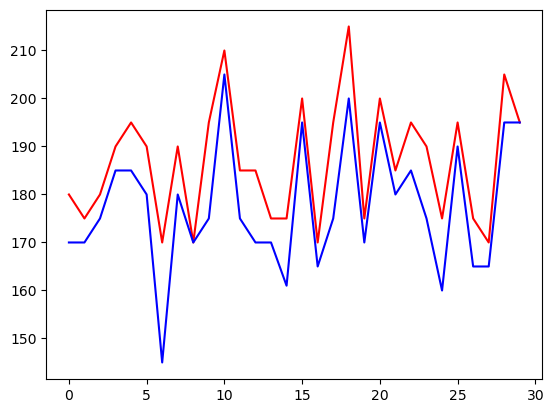

In [121]:
res_perfect =[]
res_approx = []
res_random = []
time_perfect = []
time_approx = []

import time

def compute_path_weight(G, path, weight_attr='weight'):
    return sum(G[path[i]][path[i+1]].get(weight_attr, 1) for i in range(len(path) - 1))

for i in tqdm(range(30)):
    circ = generate_random_circuit(num_qubits=10,num_gates=100)
    G, mst, adj = plot_connectivity_and_max_mst(circ, return_adjacency_matrix=True,plot=False)
    start = time.time()
    res_perfect.append(max_weight_hamiltonian_path(G)[1])
    tim = time.time() - start
    time_perfect.append(tim)

    start = time.time()
    res_approx.append(fast_approx_max_weight_hamiltonian_path(G)[1])
    tim = time.time() - start
    time_approx.append(tim)
    l = list(G.nodes)
    np.random.shuffle(l)
    res_random.append(compute_path_weight(G=G,path=l))

plt.plot(res_perfect,color='r')
plt.plot(res_approx,color='b')

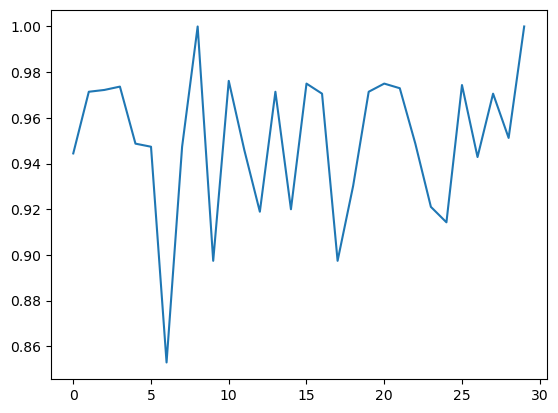

In [122]:
plt.plot([res_approx[i]/res_perfect[i] for i in range(len(res_perfect))])

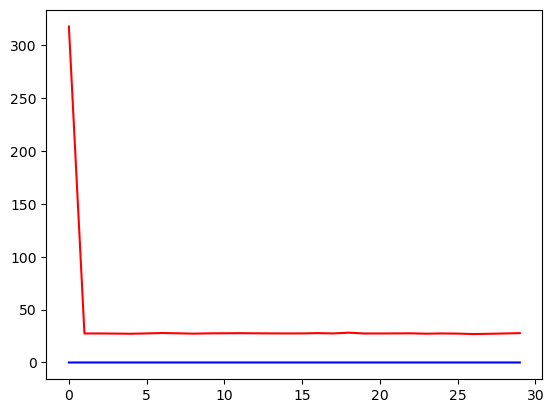

In [123]:
plt.plot(time_perfect,color='r')
plt.plot(time_approx,color='b')

In [128]:
import networkx as nx

def fast_approx_max_weight_hamiltonian_path(G):
    def greedy_path(start):
        visited = set()
        path = [start]
        visited.add(start)
        current = start

        while len(path) < len(G):
            # Select best unvisited neighbor
            next_candidates = [
                (G[current][v]['weight'], v)
                for v in G.neighbors(current)
                if v not in visited
            ]
            if not next_candidates:
                break
            _, best_next = max(next_candidates)
            path.append(best_next)
            visited.add(best_next)
            current = best_next

        return path if len(path) == len(G) else None

    def compute_path_weight(path):
        return sum(G[path[i]][path[i + 1]]['weight'] for i in range(len(path) - 1))

    best_path = None
    best_weight = -float('inf')

    # Try greedy starting from top 3 nodes by weighted degree
    weighted_degrees = sorted(G.nodes, key=lambda n: sum(G[n][nbr]['weight'] for nbr in G[n]), reverse=True)[:3]
    for start in weighted_degrees:
        path = greedy_path(start)
        if path:
            weight = compute_path_weight(path)
            if weight > best_weight:
                best_path = path
                best_weight = weight

    return best_path, best_weight
fast_approx_max_weight_hamiltonian_path(G)

([9, 2, 5, 1, 4, 8, 3, 7, 6, 0], 96)

# simulations

In [143]:
chi_range = range(5,40,3) 
N_gate_range = range(50,330,30)
nb_moy = 30
N_qubits = 10
print(list(chi_range))
print(list(N_gate_range))
print(len(chi_range)*len(N_gate_range)*nb_moy)

[5, 8, 11, 14, 17, 20, 23, 26, 29, 32, 35, 38]
[50, 80, 110, 140, 170, 200, 230, 260, 290, 320]
3600


## Moyenne

In [43]:
tree_fidelity_values = []
mps_fidelity_values = []
mps_ordered_fidelity_values = []
diff_values = []
delta_mps = []

results = []
chi_tree_moy_dic = {}
chi_mps_moy_dic = {}
chi_omps_moy_dic = {}

mem_tree_moy_dic = {}
mem_mps_moy_dic = {}
mem_omps_moy_dic = {}

for N in tqdm(N_gate_range):
    df_results = pd.DataFrame(results)
    df_results.to_csv('results_df.csv')

    for chi in chi_range:
        chi_mps_moy_dic[chi] = []
        chi_omps_moy_dic[chi] = []
        chi_tree_moy_dic[chi] = []
        mem_tree_moy_dic[chi] = []
        mem_mps_moy_dic[chi] = []
        mem_omps_moy_dic[chi] = []

    for i in range(nb_moy):
        circ = generate_random_circuit(num_qubits=N_qubits,num_gates=N,plot=False)

        for chi in chi_range:
            tree_fidelity,mps_fidelity,omps_fidelity,mem_tree,mem_mps,mem_omps = test_tree_mps(circ = circ,n_qb=N_qubits,max_bond=chi,return_memory=True)
            chi_tree_moy_dic[chi].append(tree_fidelity)
            chi_mps_moy_dic[chi].append(mps_fidelity)
            chi_omps_moy_dic[chi].append(omps_fidelity)
            mem_tree_moy_dic[chi].append(mem_tree)
            mem_mps_moy_dic[chi].append(mem_mps)
            mem_omps_moy_dic[chi].append(mem_omps)
    
    for chi in chi_range:
        results.append({
            'N': N,
            'chi': chi,
            'f_tree': np.mean(chi_tree_moy_dic[chi]),
            'f_std_tree':np.std(chi_tree_moy_dic[chi]),
            'f_mps': np.mean(chi_mps_moy_dic[chi]),
            'f_std_mps':np.std(chi_mps_moy_dic[chi]),
            'f_omps': np.mean(chi_omps_moy_dic[chi]),
            'f_std_omps':np.std(chi_omps_moy_dic[chi]),
            'mem_tree': np.mean(mem_tree_moy_dic[chi]),
            'mem_std_tree':np.std(mem_tree_moy_dic[chi]),
            'mem_mps': np.mean(mem_mps_moy_dic[chi]),
            'mem_std_mps':np.std(mem_mps_moy_dic[chi]),
            'mem_omps': np.mean(mem_omps_moy_dic[chi]),
            'mem_std_omps':np.std(mem_omps_moy_dic[chi]),
            })

df_results = pd.DataFrame(results)
df_results.to_csv('results_df.csv')

100%|██████████| 5/5 [09:36<00:00, 115.32s/it]


## Pas moyenne

In [ ]:
tree_fidelity_values = []
mps_fidelity_values = []
mps_ordered_fidelity_values = []
diff_values = []
delta_mps = []

results = []
chi_tree_moy_dic = {}
chi_mps_moy_dic = {}
chi_omps_moy_dic = {}

mem_tree_moy_dic = {}
mem_mps_moy_dic = {}
mem_omps_moy_dic = {}

for N in tqdm(N_gate_range):
    # print('N',N)
    df_results = pd.DataFrame(results)
    df_results.to_csv('results_df.csv')

    for chi in chi_range:
        chi_mps_moy_dic[chi] = []
        chi_omps_moy_dic[chi] = []
        chi_tree_moy_dic[chi] = []
        mem_tree_moy_dic[chi] = []
        mem_mps_moy_dic[chi] = []
        mem_omps_moy_dic[chi] = []

    for i in range(nb_moy):
        # print('moy',i)
        circ = generate_random_circuit(num_qubits=N_qubits,num_gates=N,plot=False)
        G, mst, adj = plot_connectivity_and_max_mst(circ, return_adjacency_matrix=True)
        # print('adjacency ok')
        perm,weight = fast_approx_max_weight_hamiltonian_path(G)
        # print('perm ok')

        for chi in chi_range:
            # print('chi',chi)
            tree_fidelity,mps_fidelity,omps_fidelity,mem_tree,mem_mps,mem_omps = test_tree_mps(circ = circ,n_qb=N_qubits,max_bond=chi,return_memory=True,G=G,adj=adj,perm=perm)
            results.append({
                'N': N,
                'chi': chi,
                'f_tree': tree_fidelity,
                'f_mps': mps_fidelity,
                'f_omps': omps_fidelity,
                'mem_tree': mem_tree,
                'mem_mps': mem_mps,
                'mem_omps': mem_omps,
                })

df_results = pd.DataFrame(results)
df_results.to_csv('results_df.csv')

 60%|██████    | 6/10 [1:43:33<1:29:17, 1339.35s/it]

In [72]:
df_results[0:20]

,N,chi,f_tree,f_mps,f_omps,mem_tree,mem_mps,mem_omps
0,50,5,0.155562,0.150681,0.143461,468,320,320
1,50,8,0.313585,0.259027,0.208633,708,680,680
2,50,11,0.493352,0.360253,0.297548,948,1004,1004
3,50,14,0.662098,0.523238,0.499134,1188,1400,1400
4,50,17,0.827755,0.691485,0.756749,1348,1768,1768
5,50,20,0.889003,0.778862,0.848367,1348,1960,1960
6,50,23,0.934037,0.862453,0.922325,1348,2152,2152
7,50,26,0.964884,0.947993,0.972632,1348,2344,2344
8,50,29,0.985035,0.986442,0.994893,1348,2536,2536
9,50,32,1.000000,1.000000,1.000000,1348,2728,2728


# plot

In [75]:
df_results.to_csv('results_df.csv')

In [52]:
df_results = pd.read_csv('results_df_10qb_20moy_chi_1-50-3_N_30-300-30.csv')

In [3]:
df_results = pd.read_csv('results_df_big.csv')  

In [134]:
df_results[0:40]

,N,chi,f_tree,f_mps,f_omps,mem_tree,mem_mps,mem_omps
0,50,5,0.343448,0.146540,0.298142,748,320,320
1,50,8,0.717753,0.231706,0.318501,1156,680,680
2,50,11,0.838014,0.370205,0.515904,1156,1004,1004
3,50,14,0.932953,0.602753,0.658035,1156,1400,1400
4,50,17,1.000000,0.861813,0.780021,1156,1768,1768
5,50,20,1.000000,0.915528,0.854334,1156,1960,1960
6,50,23,1.000000,0.946590,0.919523,1156,2152,2152
7,50,26,1.000000,0.974666,0.963800,1156,2344,2344
8,50,29,1.000000,0.991860,0.993965,1156,2536,2536
9,50,32,1.000000,1.000000,1.000000,1156,2728,2728


In [135]:
# N,CHI,RES_tree,RES_mps,RES_omps,MEM_tree,MEM_mps,MEM_omps = zip(*results)

N = df_results['N']
CHI = df_results['chi']
RES_tree = df_results['f_tree']
RES_mps = df_results['f_mps']
RES_omps = df_results['f_omps']
MEM_tree = df_results['mem_tree']
MEM_mps = df_results['mem_mps']
MEM_omps = df_results['mem_omps']

chi_range = range(int(np.min(CHI)),int(np.max(CHI))+1,int(CHI[1]-CHI[0]))
N_gate_range = range(int(np.min(N)),int(np.max(N))+1,int(N[len(chi_range)]-N[0]))

# RES = np.array(RES).reshape(len(N),len(CHI))
N = np.array(N).reshape(len(N_gate_range),len(chi_range))
CHI = np.array(CHI).reshape(len(N_gate_range),len(chi_range))
RES_tree = np.array(RES_tree).reshape(len(N_gate_range),len(chi_range))
RES_mps = np.array(RES_mps).reshape(len(N_gate_range),len(chi_range))
RES_omps = np.array(RES_omps).reshape(len(N_gate_range),len(chi_range))
MEM_tree = np.array(MEM_tree).reshape(len(N_gate_range),len(chi_range))
MEM_mps = np.array(MEM_mps).reshape(len(N_gate_range),len(chi_range))
MEM_omps = np.array(MEM_omps).reshape(len(N_gate_range),len(chi_range))

# plt.plot(MEM_tree[i],RES_tree[i],color='g')
# plt.plot(MEM_mps[i],RES_mps[i],color='r')
# plt.show()


fig = plt.figure()
gs = fig.add_gridspec(1, len(N.T[0]), hspace=0, wspace=0)
axes = gs.subplots(sharex='col', sharey='row')
fig.suptitle('Fidelity by Nb of Coef for different number of Gates')
fig.supxlabel('Nb Coef')
fig.supylabel('Fidelity')

# fig, axes = plt.subplots(1,9,sharey=True)

for i in range(len(N.T[0])):
    axes[i].plot(MEM_tree[i],RES_tree[i],color = 'g',label = 'Tree')
    axes[i].plot(MEM_mps[i],RES_mps[i],color = 'r',label = 'Mps')
    axes[i].plot(MEM_omps[i],RES_omps[i],color = 'b',label = 'oMps')
    axes[i].set_title('N='+str(int(N.T[0][i])))

axes[-1].legend()
# for ax in axes.flat:
#     ax.set(xlabel='Nb Coef', ylabel='Fidelity')
for ax in axes.flat:
    ax.label_outer()

plt.tight_layout()

plt.show()

ValueError: range() arg 3 must not be zero

## tidying

In [137]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tidy dataframe creation (as before)
df = pd.DataFrame(df_results)

methods = ['tree', 'mps', 'omps']
tidy_df = pd.DataFrame()

for method in methods:
    method_df = pd.DataFrame({
        'N': df['N'],
        'chi': df['chi'],
        'method': method.upper(),
        'fidelity': df[f'f_{method}'] if f'f_{method}' in df else df[f'fidelity_{method}'],
        # 'fidelity_std': df[f'f_std_{method}'],
        'memory': df[f'mem_{method}']#,
        # 'memory_std': df[f'mem_std_{method}']
        # 'circuit':df['circuit']
    })
    tidy_df = pd.concat([tidy_df, method_df], ignore_index=True)

In [138]:
tidy_df[tidy_df['method']== 'MPS' ]

,N,chi,method,fidelity,memory
360,50,5,MPS,0.146540,320
361,50,8,MPS,0.231706,680
362,50,11,MPS,0.370205,1004
363,50,14,MPS,0.602753,1400
364,50,17,MPS,0.861813,1768
...,...,...,...,...,...
715,110,26,MPS,0.820652,2344
716,110,29,MPS,0.971710,2536
717,110,32,MPS,1.000000,2728
718,110,35,MPS,1.000000,2728


## fidelity on mem

KeyError: 'fidelity_std'

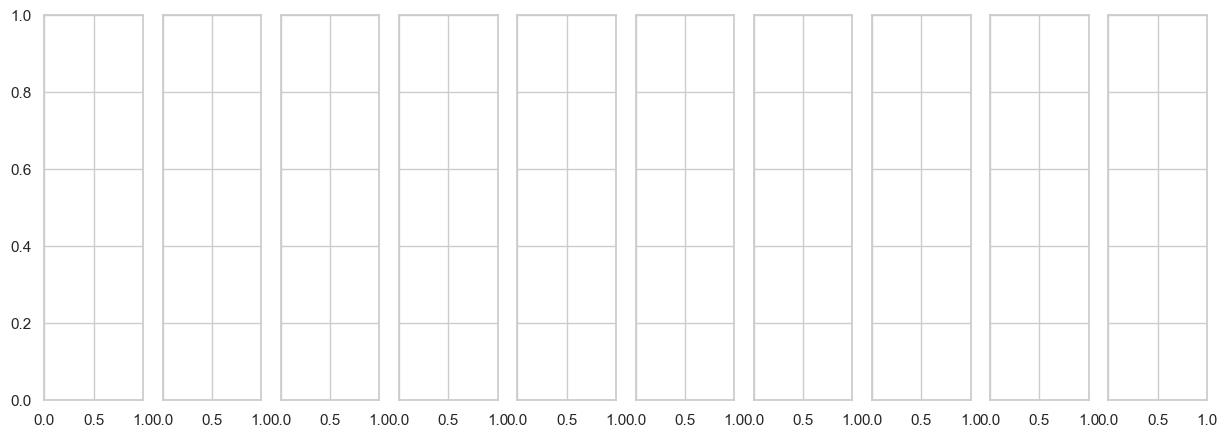

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="notebook")

unique_Ns = sorted(tidy_df['N'].unique())
# ncols = 2
# nrows = (len(unique_Ns) + 1) // ncols
ncols = len(unique_Ns)
nrows = 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(1.5 * ncols, 5 * nrows), sharex=False, sharey=True)
axes = axes.flatten()

palette = {'TREE': 'C0', 'MPS': 'C1', 'OMPS': 'C2'}

for i, N_val in enumerate(unique_Ns):
    ax = axes[i]
    subset = tidy_df[tidy_df['N'] == N_val]

    for method in ['TREE', 'MPS', 'OMPS']:
        sub = subset[subset['method'] == method]
        
        # Sort by memory to avoid jagged lines
        sub = sub.sort_values(by='memory')
        
        # Plot line
        # ax.plot(sub['memory'], sub['fidelity'], label=method, color=palette[method])
        ax.errorbar(sub['memory'],sub['fidelity'],yerr = sub['fidelity_std'],xerr=sub['memory_std'])
        
        # Plot error band
        # ax.fill_between(
        #     sub['memory'],
        #     sub['fidelity'] - sub['fidelity_std'],
        #     sub['fidelity'] + sub['fidelity_std'],
        #     alpha=0.2,
        #     color=palette[method]
        # )
        # ax.fill_between(
        #     sub['memory'],
        #     sub['memory'] - sub['memory_std'],
        #     sub['memory'] + sub['memory_std'],
        #     alpha=0.2,
        #     color=palette[method]
        # )

    ax.set_title(f'N = {N_val}')
    ax.set_xlabel('Nb. of \n Complex \n Coef.')
    # ax.set_ylabel('Fidelity')
    # ax.legend()
    ax.grid(True)

axes[0].set_ylabel('Fidelity')
axes[0].legend()

# Clean up unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Fidelity vs Number of complex coefficients')

plt.tight_layout()
plt.show()

In [139]:
tidy_df.head()

,N,chi,method,fidelity,memory
0,50,5,TREE,0.343448,748
1,50,8,TREE,0.717753,1156
2,50,11,TREE,0.838014,1156
3,50,14,TREE,0.932953,1156
4,50,17,TREE,1.000000,1156


ValueError: x and y must be the same size

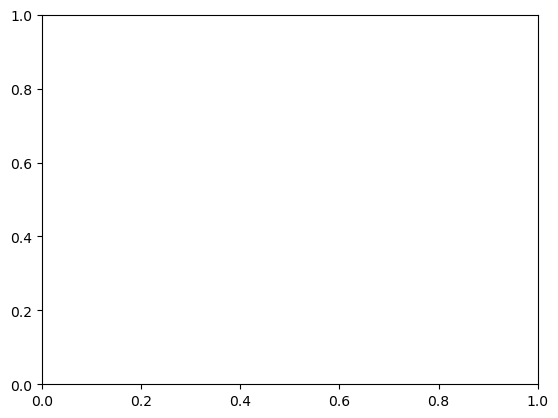

In [140]:
from scipy.optimize import curve_fit

plt.scatter(tidy_df[tidy_df['N']==320]['memory'],tidy_df[tidy_df['N']==50]['fidelity'])
XY = list(zip(subset['memory'],subset['fidelity']))
XY.sort(key=lambda i : i[0])
X,Y = list(zip(*XY))


fit = Polynomial.fit(X,Y,deg = 1)
plt.plot(X,fit(np.array(X)))

# def sigmoid(x, A, B):
#     y = np.multiply(A,(1/(1+np.exp(B-x))))
#     return y

# parameters, covariance = curve_fit(sigmoid, X, Y)
# print(parameters)

# plt.plot(X,sigmoid(X,*parameters))
# plt.plot(np.linspace(-10,10,100),sigmoid(np.linspace(-10,10,100),1,0))

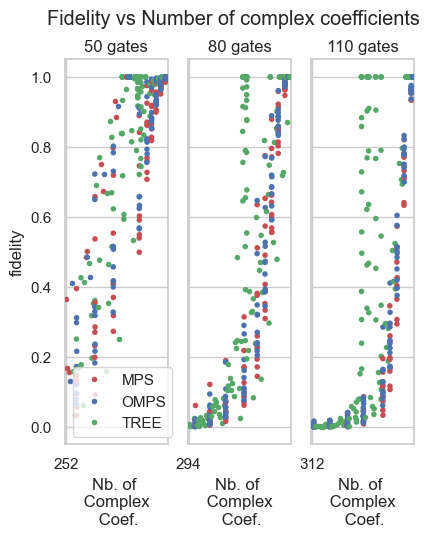

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

sns.set(style="whitegrid", context="notebook")

unique_Ns = sorted(tidy_df['N'].unique())
# ncols = 2
# nrows = (len(unique_Ns) + 1) // ncols
ncols = len(unique_Ns)
nrows = 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(1.5 * ncols, 5 * nrows), sharex=False, sharey=True)
axes = axes.flatten()

palette = {'TREE': 'C0', 'MPS': 'C1', 'OMPS': 'C2'}

for i, N_val in enumerate(unique_Ns):
    ax = axes[i]
    subset = tidy_df[tidy_df['N'] == N_val]

    plot = sns.stripplot(data=subset,x='memory',y='fidelity',hue='method',ax=ax,palette={'MPS':'r','OMPS':'b','TREE':'g'},s=4 )
    
    # for method in ['TREE','MPS','OMPS']:
    #     X = subset['memory']
    #     Y = subset['fidelity']
    #     fit = Polynomial.fit(X,Y,deg = 10)
    #     plot_fit = plt.plot(x = subset)

    ax.xaxis.grid(True)
    ax.set_title(f'{N_val} gates')
    ax.get_legend().remove()
    ax.set_xlabel('Nb. of \n Complex \n Coef.')
    # print(ax.get_xticks())
    ax.set_xticks(ax.get_xticks()[::90][0:3])
    # ax.set_ylabel('Fidelity')
    # ax.legend()
    # ax.grid(True)

# axes[0].set_ylabel('Fidelity')
axes[0].legend()

# Clean up unused axes
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

fig.suptitle('Fidelity vs Number of complex coefficients')

# plt.tight_layout()
plt.show()

In [ ]:
from numpy.polynomial import Polynomial
c = Polynomial.fit([1,2,3,8,9,10],[1,2,3,8,9,10],deg = 1)
# help(c)

3.0000000000000004

## mem for min f on N

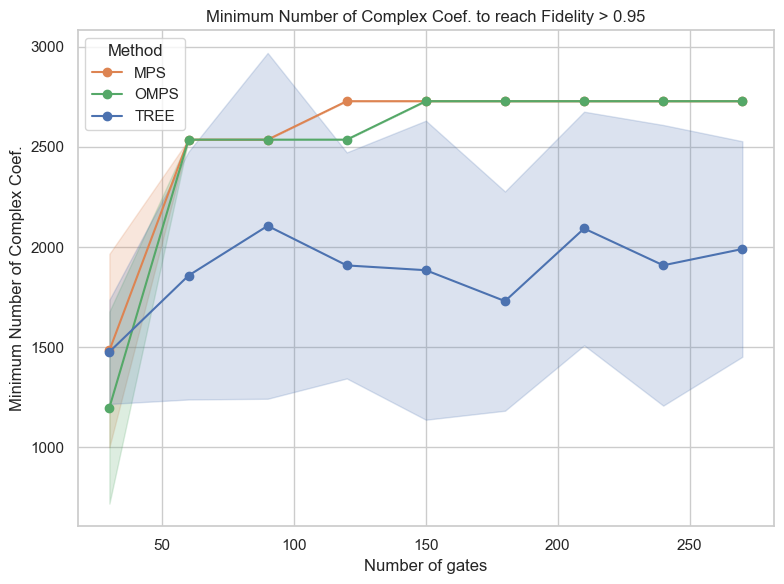

In [26]:
threshold = 0.95

# Conservative fidelity: subtract std to ensure it's safely above the threshold
conservative_df = tidy_df[tidy_df['fidelity'] - tidy_df['fidelity_std'] > threshold]

# For each N and method, get the row with min memory
min_mem_with_uncertainty = (
    conservative_df
    .sort_values('memory')
    .groupby(['N', 'method'], as_index=False)
    .first()  # First row after sorting by memory == minimum memory
)

# Rename for clarity
min_mem_with_uncertainty = min_mem_with_uncertainty.rename(columns={
    'memory': 'min_mem',
    'memory_std': 'min_mem_std'
})


sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))

methods = min_mem_with_uncertainty['method'].unique()
palette = {'TREE': 'C0', 'MPS': 'C1', 'OMPS': 'C2'}

for method in methods:
    sub = min_mem_with_uncertainty[min_mem_with_uncertainty['method'] == method]
    
    # Sort for line plotting
    sub = sub.sort_values(by='N')
    
    # Plot line
    plt.plot(sub['N'], sub['min_mem'], label=method, marker='o', color=palette[method])
    
    # Plot error band
    plt.fill_between(
        sub['N'],
        sub['min_mem'] - sub['min_mem_std'],
        sub['min_mem'] + sub['min_mem_std'],
        alpha=0.2,
        color=palette[method]
    )

plt.title(f"Minimum Number of Complex Coef. to reach Fidelity > {threshold}")
plt.xlabel("Number of gates")
plt.ylabel("Minimum Number of Complex Coef.")
plt.legend(title="Method")
plt.tight_layout()
plt.show()

## no moy

In [27]:
tidy_df

,N,chi,method,fidelity,memory
0,50,5,TREE,0.084390,328
1,50,8,TREE,0.184141,688
2,50,11,TREE,0.300721,880
3,50,14,TREE,0.439311,1072
4,50,17,TREE,0.583527,1264
...,...,...,...,...,...
4855,290,17,OMPS,0.000812,1768
4856,290,20,OMPS,0.006164,1960
4857,290,23,OMPS,0.047196,2152
4858,290,26,OMPS,0.326601,2344


<Figure size 800x600 with 0 Axes>

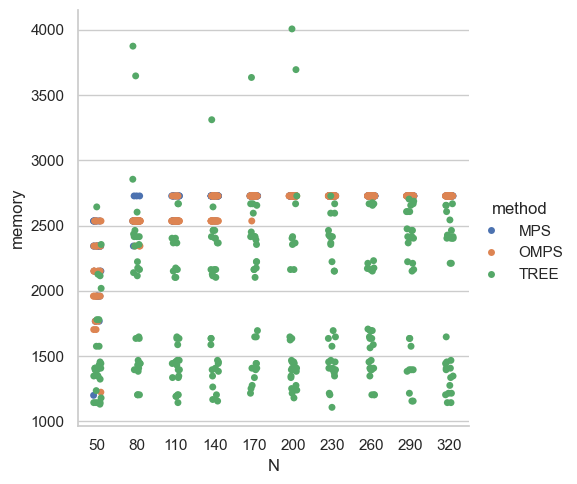

In [100]:
threshold = 0.95

above_df = (
    tidy_df[tidy_df['fidelity'] > threshold]
    .sort_values('memory')
    .groupby(['N', 'method','circuit'], as_index=False)
    .first()  # First row after sorting by memory == minimum memory
)

sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))

sns.catplot(data=above_df,x='N',y='memory',hue='method')

# plt.title(f"Minimum Number of Complex Coef. to reach Fidelity > {threshold}")
# plt.xlabel("Number of gates")
# plt.ylabel("Minimum Number of Complex Coef.")
# plt.legend(title="Method")
# plt.tight_layout()
plt.show()